# EDA: Цены на дома

Этот ноутбук показывает практический EDA для соревнования `House Prices - Advanced Regression Techniques`.
Здесь мы проверяем таргет, пропуски, категориальные сигналы, выбросы и различия между train/test, чтобы решения для модели опирались на данные, а не на декоративные графики.

## Что здесь проверяем

- Насколько сильно перекошен таргет `SalePrice` и почему почти везде нужен `log1p(SalePrice)`.
- Какие признаки действительно двигают цену: `OverallQual`, `GrLivArea`, `Neighborhood`, размеры дома, возраст дома и наличие гаража.
- Где пропуски несут смысл, а где это просто незаполненные значения, которые нужно обрабатывать отдельно.
- Чем train отличается от test по пропускам и распределениям, чтобы не строить модель на скрытом сдвиге.

Это EDA сделан как рабочий документ: сначала форма данных, потом сигналы, потом конкретные выводы для моделирования.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid")

# Notebook works both from project root and from notebooks/
candidate_roots = [Path.cwd(), Path.cwd().parent]
project_root = next((p for p in candidate_roots if (p / "data" / "train.csv").exists()), None)
if project_root is None:
    raise FileNotFoundError(
        "Не найден data/train.csv. Откройте ноутбук из папки проекта или проверьте структуру data/."
    )

data_dir = project_root / "data"
train = pd.read_csv(data_dir / "train.csv")
test = pd.read_csv(data_dir / "test.csv")

train["SalePriceLog"] = np.log1p(train["SalePrice"])

print(f"Текущая рабочая папка: {Path.cwd()}")
print(f"Используемая папка данных: {data_dir}")
display(train.head())
print(f"Форма train: {train.shape}")
print(f"Форма test: {test.shape}")
print(f"Средняя цена продажи: {train['SalePrice'].mean():.0f}")
print(f"Медиана цены продажи: {train['SalePrice'].median():.0f}")
print(f"Среднее log1p(SalePrice): {train['SalePriceLog'].mean():.3f}")

Текущая рабочая папка: /home/pavel/house_prices_kaggle/notebooks
Используемая папка данных: /home/pavel/house_prices_kaggle/data


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice,SalePriceLog
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,NaN,NaN,NaN,0,2,2008,WD,Normal,208500,12.247699
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,NaN,NaN,NaN,0,5,2007,WD,Normal,181500,12.109016
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,NaN,NaN,NaN,0,9,2008,WD,Normal,223500,12.317171
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000,11.849405
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,NaN,NaN,NaN,0,12,2008,WD,Normal,250000,12.429220


Форма train: (1460, 82)
Форма test: (1459, 80)
Средняя цена продажи: 180921
Медиана цены продажи: 163000
Среднее log1p(SalePrice): 12.024


In [2]:
print("Скьюнесс таргета:")
print(f"SalePrice skew = {train['SalePrice'].skew():.3f}")
print(f"SalePriceLog skew = {train['SalePriceLog'].skew():.3f}")

missing = train.isna().mean().sort_values(ascending=False).head(10)
display(missing.rename("missing_share").to_frame())

print("Быстрый взгляд на самые дорогие дома:")
display(train.sort_values("SalePrice", ascending=False)[["SalePrice", "SalePriceLog", "OverallQual", "GrLivArea", "Neighborhood"]].head(8))

Скьюнесс таргета:
SalePrice skew = 1.883
SalePriceLog skew = 0.121


,missing_share
PoolQC,0.995205
MiscFeature,0.963014
Alley,0.937671
Fence,0.807534
MasVnrType,0.597260
FireplaceQu,0.472603
LotFrontage,0.177397
GarageQual,0.055479
GarageYrBlt,0.055479
GarageFinish,0.055479


Быстрый взгляд на самые дорогие дома:


,SalePrice,SalePriceLog,OverallQual,GrLivArea,Neighborhood
691,755000,13.534474,10,4316,NoRidge
1182,745000,13.521141,10,4476,NoRidge
1169,625000,13.345509,10,3627,NoRidge
898,611657,13.323929,9,2364,NridgHt
803,582933,13.275829,9,2822,NridgHt
1046,556581,13.229570,9,2868,StoneBr
440,555000,13.226725,10,2402,NridgHt
769,538000,13.195616,8,3279,StoneBr


### Гипотезы перед моделированием

- Таргет `SalePrice` правоскошен, поэтому `log1p(SalePrice)` должен стабилизировать обучение.
- Цена определяется не только метражом: качество дома и локация дают отдельный сильный сигнал.
- Пропуски неоднородны и могут вести себя по-разному в train и test, значит нужен контролируемый imputation.
- Возможны выбросы по площади и `LotArea`, которые влияют на ошибки сильнее средней точки.

Ниже проверка сделана как инженерный чеклист: сигнал -> риск -> решение в пайплайне.

Идея: log1p сжимает правый хвост и делает таргет более симметричным.
Это полезно для линейных моделей и для стабильной оценки ошибки на дорогих домах.


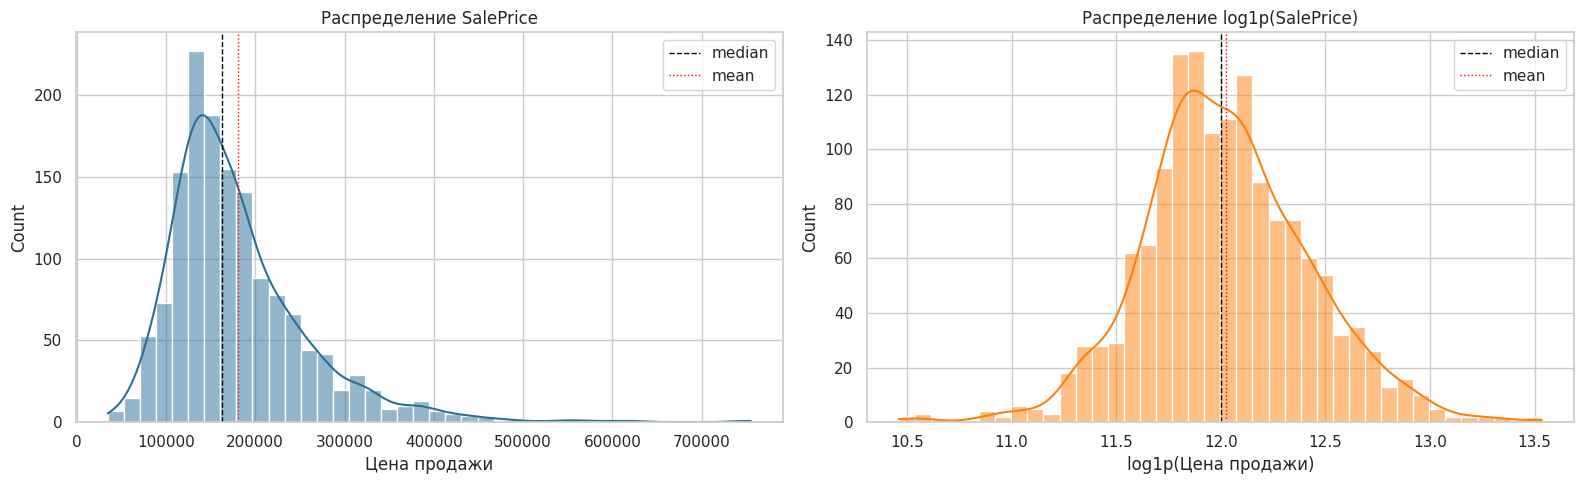

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.histplot(train["SalePrice"], bins=40, kde=True, ax=axes[0], color="#2a6f97")
axes[0].axvline(train["SalePrice"].median(), color="black", linestyle="--", linewidth=1, label="median")
axes[0].axvline(train["SalePrice"].mean(), color="red", linestyle=":", linewidth=1, label="mean")
axes[0].set_title("Распределение SalePrice")
axes[0].set_xlabel("Цена продажи")
axes[0].legend()

sns.histplot(train["SalePriceLog"], bins=40, kde=True, ax=axes[1], color="#ff7f0e")
axes[1].axvline(train["SalePriceLog"].median(), color="black", linestyle="--", linewidth=1, label="median")
axes[1].axvline(train["SalePriceLog"].mean(), color="red", linestyle=":", linewidth=1, label="mean")
axes[1].set_title("Распределение log1p(SalePrice)")
axes[1].set_xlabel("log1p(Цена продажи)")
axes[1].legend()

plt.tight_layout()

print("Идея: log1p сжимает правый хвост и делает таргет более симметричным.")
print("Это полезно для линейных моделей и для стабильной оценки ошибки на дорогих домах.")

Самые сильные числовые связи с log1p(SalePrice):


,corr_with_log_price
SalePrice,0.948374
OverallQual,0.817185
GrLivArea,0.700927
GarageCars,0.680625
GarageArea,0.650888
TotalBsmtSF,0.612134
1stFlrSF,0.596981
FullBath,0.594771
YearBuilt,0.586570
YearRemodAdd,0.565608


Сильные категории, которые полезно кодировать отдельно:


,Neighborhood,median_saleprice,count
16,NridgHt,315000.0,77
15,NoRidge,301500.0,41
22,StoneBr,278000.0,25
23,Timber,228475.0,38
21,Somerst,225500.0,86
6,Crawfor,200624.0,51
4,ClearCr,200250.0,28
5,CollgCr,197200.0,150
14,NWAmes,182900.0,73
8,Gilbert,181000.0,79


Примеры возможных выбросов по GrLivArea: очень большая площадь, но цена не растет пропорционально.


,GrLivArea,SalePrice,OverallQual,Neighborhood
1298,5642,160000,10,Edwards
523,4676,184750,10,Edwards
1182,4476,745000,10,NoRidge
691,4316,755000,10,NoRidge
1169,3627,625000,10,NoRidge
185,3608,475000,10,OldTown
304,3493,295000,7,OldTown
1268,3447,381000,8,Crawfor


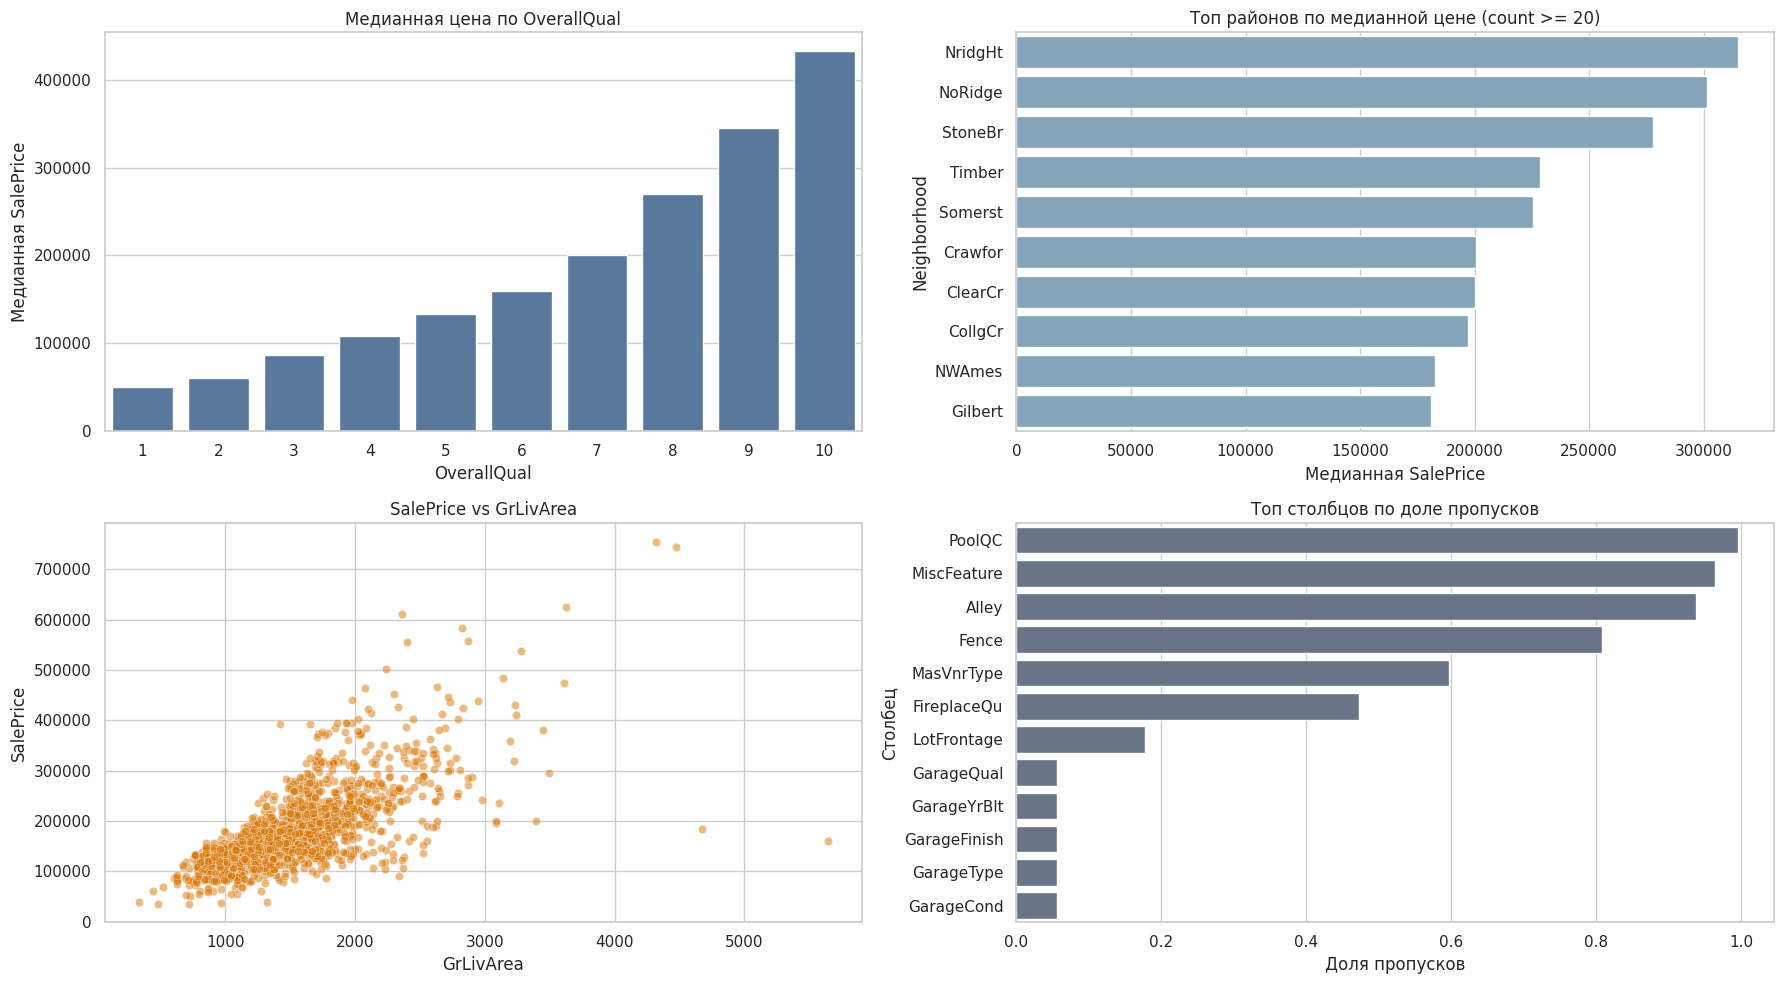

In [3]:
fig, axes = plt.subplots(2, 2, figsize=(18, 10))

# 1) Самый сильный числовой сигнал: OverallQual
overall_qual = train.groupby("OverallQual", as_index=False)["SalePrice"].median().sort_values("OverallQual")
sns.barplot(data=overall_qual, x="OverallQual", y="SalePrice", ax=axes[0, 0], color="#4c78a8")
axes[0, 0].set_title("Медианная цена по OverallQual")
axes[0, 0].set_xlabel("OverallQual")
axes[0, 0].set_ylabel("Медианная SalePrice")

# 2) Район как сильный категориальный признак
neighborhood_stats = train.groupby("Neighborhood", as_index=False)["SalePrice"].agg(["median", "count"]).reset_index()
neighborhood_top = neighborhood_stats.query("count >= 20").sort_values("median", ascending=False).head(10)
sns.barplot(data=neighborhood_top, y="Neighborhood", x="median", ax=axes[0, 1], color="#7aa6c2")
axes[0, 1].set_title("Топ районов по медианной цене (count >= 20)")
axes[0, 1].set_xlabel("Медианная SalePrice")
axes[0, 1].set_ylabel("Neighborhood")

# 3) Площадь жилой части: сильная связь, но с выбросами
sns.scatterplot(data=train, x="GrLivArea", y="SalePrice", ax=axes[1, 0], alpha=0.5, color="#d97706")
axes[1, 0].set_title("SalePrice vs GrLivArea")
axes[1, 0].set_xlabel("GrLivArea")
axes[1, 0].set_ylabel("SalePrice")

# 4) Пропуски и числовые связи с log-таргетом
missing = train.isna().mean().sort_values(ascending=False).head(12)
num_cols = train.select_dtypes(include=["number"]).columns
corr = train[num_cols].corr(numeric_only=True)["SalePriceLog"].sort_values(ascending=False)
strong_corr = corr.drop("SalePriceLog").head(10)

sns.barplot(x=missing.values, y=missing.index, ax=axes[1, 1], color="#64748b")
axes[1, 1].set_title("Топ столбцов по доле пропусков")
axes[1, 1].set_xlabel("Доля пропусков")
axes[1, 1].set_ylabel("Столбец")

plt.tight_layout()

print("Самые сильные числовые связи с log1p(SalePrice):")
display(strong_corr.rename("corr_with_log_price").to_frame())
print("Сильные категории, которые полезно кодировать отдельно:")
display(neighborhood_top[["Neighborhood", "median", "count"]].rename(columns={"median": "median_saleprice"}))
print("Примеры возможных выбросов по GrLivArea: очень большая площадь, но цена не растет пропорционально.")
display(train.sort_values("GrLivArea", ascending=False)[["GrLivArea", "SalePrice", "OverallQual", "Neighborhood"]].head(8))

### Train/Test и категориальные сигналы

Ниже я сравниваю train и test по пропускам и смотрю на категории, которые реально двигают цену. Это помогает понять, где есть сдвиг между частями датасета и какие категориальные признаки стоит кодировать особенно аккуратно.

In [ ]:
# Сравнение train/test по пропускам
train_missing = train.isna().mean().sort_values(ascending=False)
test_missing = test.isna().mean().sort_values(ascending=False)
missing_compare = pd.concat([train_missing, test_missing], axis=1)
missing_compare.columns = ["train_missing", "test_missing"]
missing_compare["gap"] = (missing_compare["train_missing"] - missing_compare["test_missing"]).abs()
display(missing_compare.sort_values("gap", ascending=False).head(15))

# Категориальные признаки, которые реально двигают цену
cat_focus = ["Neighborhood", "MSZoning", "ExterQual", "KitchenQual", "GarageType", "BsmtQual", "CentralAir", "Foundation", "HouseStyle"]
cat_summary = []
for col in cat_focus:
    if col in train.columns:
        tmp = train.groupby(col, dropna=False)["SalePrice"].agg(["median", "count"]).reset_index()
        tmp.columns = [col, "median_saleprice", "count"]
        tmp["feature"] = col
        cat_summary.append(tmp)
cat_summary_df = pd.concat(cat_summary, ignore_index=True)
display(cat_summary_df.sort_values(["feature", "median_saleprice"], ascending=[True, False]).head(30))

print("Главная мысль: пропуски в train и test не всегда совпадают, поэтому простое заполнение одним числом может скрыть сдвиг между частями данных.")
print("Категориальные признаки вроде Neighborhood и ExterQual дают заметный вклад в цену, значит для них нужен аккуратный preprocessing, а не игнорирование.")

In [ ]:
# Корреляции числовых признаков с log-таргетом
num_cols = train.select_dtypes(include=["number"]).columns
corr_with_target = train[num_cols].corr(numeric_only=True)["SalePriceLog"].sort_values(ascending=False)
display(corr_with_target.drop("SalePriceLog").head(15).rename("corr_with_log_price").to_frame())

fig, ax = plt.subplots(figsize=(10, 8))
top_numeric = corr_with_target.drop("SalePriceLog").head(12).sort_values()
sns.barplot(x=top_numeric.values, y=top_numeric.index, ax=ax, color="#4c78a8")
ax.set_title("Топ числовых признаков по корреляции с log1p(SalePrice)")
ax.set_xlabel("Correlation")
ax.set_ylabel("Feature")
plt.tight_layout()

print("Выбросы по площади и цене стоит проверять отдельно: особенно большие GrLivArea не всегда означают пропорционально дорогой дом.")
display(train.sort_values("GrLivArea", ascending=False)[["GrLivArea", "SalePrice", "SalePriceLog", "OverallQual", "Neighborhood"]].head(10))

### Пропуски и target по категориям

Здесь я показываю, где пропуски реально отличаются между train и test, и как цена ведет себя внутри ключевых категорий. Это уже не просто описание данных, а проверка гипотез для preprocessing и feature engineering.

In [ ]:
# Heatmap сравнения пропусков между train и test
missing_view = missing_compare.sort_values("gap", ascending=False).head(15)[["train_missing", "test_missing"]]
fig, ax = plt.subplots(figsize=(8, 7))
sns.heatmap(missing_view, annot=True, fmt=".2f", cmap="Blues", ax=ax, cbar=False)
ax.set_title("Train/Test missingness comparison")
ax.set_xlabel("Dataset")
ax.set_ylabel("Feature")
plt.tight_layout()

print("Если у признака заметно различаются пропуски в train и test, для него особенно важно делать заполнение осознанно, а не по шаблону.")

# Target по ключевым категориям
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
cat_box_features = ["Neighborhood", "ExterQual", "KitchenQual", "GarageType"]
for ax, col in zip(axes.flatten(), cat_box_features):
    if col in train.columns:
        order = train.groupby(col)["SalePrice"].median().sort_values(ascending=False).index
        top_values = train[col].value_counts().head(8).index
        subset = train[train[col].isin(top_values)]
        sns.boxplot(data=subset, x=col, y="SalePrice", order=order if col == "Neighborhood" else None, ax=ax)
        ax.set_title(f"SalePrice by {col}")
        ax.tick_params(axis='x', rotation=45)
    else:
        ax.axis('off')
plt.tight_layout()

print("Категории вроде ExterQual и KitchenQual дают четкую сегментацию цены, поэтому их лучше сохранять как отдельные сигналы, а не смешивать в шуме.")

### Drift, leakage и устойчивость к выбросам

Ниже блоки, которые отличают просто красивый EDA от реально полезного:
- где train и test расходятся по распределениям;
- есть ли признаки, похожие на leakage/технические ID;
- насколько экстремальные объекты портят картину и как это учитывать в модели.

In [ ]:
# 1) Train/Test drift audit для числовых признаков (PSI на квантильных бинах)
def calc_psi(train_series, test_series, bins=10, eps=1e-6):
    train_vals = pd.to_numeric(train_series, errors="coerce").dropna()
    test_vals = pd.to_numeric(test_series, errors="coerce").dropna()
    if train_vals.nunique() < 5 or test_vals.nunique() < 5:
        return np.nan
    quantiles = np.linspace(0, 1, bins + 1)
    edges = np.unique(np.quantile(train_vals, quantiles))
    if len(edges) < 3:
        return np.nan
    train_hist, _ = np.histogram(train_vals, bins=edges)
    test_hist, _ = np.histogram(test_vals, bins=edges)
    train_pct = train_hist / max(train_hist.sum(), 1)
    test_pct = test_hist / max(test_hist.sum(), 1)
    train_pct = np.clip(train_pct, eps, None)
    test_pct = np.clip(test_pct, eps, None)
    return float(np.sum((train_pct - test_pct) * np.log(train_pct / test_pct)))

feature_cols = [c for c in train.columns if c not in ["SalePrice", "SalePriceLog", "Id"] and c in test.columns]
num_features = train[feature_cols].select_dtypes(include=["number"]).columns
psi_rows = []
for col in num_features:
    psi_rows.append({"feature": col, "psi": calc_psi(train[col], test[col])})
psi_df = pd.DataFrame(psi_rows).dropna().sort_values("psi", ascending=False)
display(psi_df.head(15))

fig, ax = plt.subplots(figsize=(10, 6))
top_psi = psi_df.head(12).sort_values("psi")
sns.barplot(data=top_psi, x="psi", y="feature", color="#1d6996", ax=ax)
ax.set_title("Top numeric train/test drift by PSI")
ax.set_xlabel("PSI")
ax.set_ylabel("Feature")
plt.tight_layout()

In [ ]:
# 2) Категориальный drift и проверка признаков, похожих на leakage
cat_features = train[feature_cols].select_dtypes(exclude=["number"]).columns
cat_drift_rows = []
for col in cat_features:
    tr = train[col].fillna("<NA>").astype(str).value_counts(normalize=True)
    te = test[col].fillna("<NA>").astype(str).value_counts(normalize=True)
    idx = tr.index.union(te.index)
    tvd = 0.5 * np.abs(tr.reindex(idx, fill_value=0) - te.reindex(idx, fill_value=0)).sum()
    cat_drift_rows.append({"feature": col, "tvd": float(tvd), "train_nunique": int(train[col].nunique(dropna=False))})
cat_drift_df = pd.DataFrame(cat_drift_rows).sort_values("tvd", ascending=False)
display(cat_drift_df.head(15))

num_corr = train.select_dtypes(include=["number"]).corr(numeric_only=True)["SalePriceLog"].dropna().sort_values(ascending=False)
leakage_candidates = num_corr[(num_corr.abs() > 0.98) & (~num_corr.index.isin(["SalePriceLog", "SalePrice"]))]
print("Potential leakage-like numeric features (|corr| > 0.98):")
display(leakage_candidates.rename("corr_with_log_price").to_frame())

id_like = [c for c in feature_cols if train[c].nunique(dropna=False) > 0.95 * len(train)]
print("High-cardinality technical-like features (review manually):")
display(pd.DataFrame({"feature": id_like}).head(20))

In [ ]:
# 3) Устойчивость к выбросам: чувствительность target к хвостам распределений
def iqr_flags(s, k=1.5):
    q1, q3 = s.quantile([0.25, 0.75])
    iqr = q3 - q1
    low, high = q1 - k * iqr, q3 + k * iqr
    return (s < low) | (s > high)

for col in ["GrLivArea", "LotArea", "TotalBsmtSF"]:
    if col in train.columns:
        flag = iqr_flags(train[col])
        stat = pd.DataFrame(
            {
                "group": ["non_outlier", "outlier"],
                "count": [int((~flag).sum()), int(flag.sum())],
                "median_saleprice": [float(train.loc[~flag, "SalePrice"].median()), float(train.loc[flag, "SalePrice"].median())],
                "median_log_price": [float(train.loc[~flag, "SalePriceLog"].median()), float(train.loc[flag, "SalePriceLog"].median())],
            }
        )
        print(f"Outlier impact by {col}:")
        display(stat)

decision_table = pd.DataFrame(
    [
        ["Target transform", "Strong right skew in SalePrice", "Train on log1p(SalePrice), invert with expm1"],
        ["Missing values", "Train/test missingness gap in some features", "Column-wise imputation + missing indicators for high-gap features"],
        ["Categorical encoding", "Neighborhood/quality categories segment target strongly", "Keep categorical signal; use robust encoding in CV"],
        ["Drift control", "Some numeric/categorical features drift between train/test", "Prefer robust models and avoid overfitting unstable features"],
        ["Outlier policy", "Tail observations shift error behavior", "Use robust loss/models and inspect extreme area-based records"],
    ],
    columns=["Decision", "Evidence from EDA", "Action in pipeline"],
)
print("Modeling contract from EDA:")
display(decision_table)

## Итог: решения, а не просто графики

| Зона | Что доказали в EDA | Что делаем в пайплайне |
|---|---|---|
| Target | `SalePrice` заметно правоскошен | Обучаемся на `log1p(SalePrice)`, инвертируем через `expm1` |
| Missingness | Есть признаки с заметным train/test gap по пропускам | Делаем осознанный imputation по колонкам + missing indicators |
| Categorical signal | Качество и район дают сильную сегментацию цены | Не выкидываем категории, кодируем их стабильно в CV |
| Drift risk | Есть признаки с повышенным drift | Снижаем зависимость от нестабильных фич, проверяем устойчивость OOF |
| Outliers | Хвосты по площади и участку влияют на ошибку | Робастные модели/лоссы и ручная проверка крайних наблюдений |

Этот ноутбук теперь отвечает на главный практический вопрос: какие решения по признакам, валидации и модели напрямую следуют из данных.